# 3. Exploratory Data Analysis and Diagnostics

Every figure here is built from the cached event table alone, no model is fitted, so this
stage runs in seconds and can be iterated freely.

Three of these figures are not decoration; they are the evidence for open findings in the
methodology audit that had previously been asserted only in prose:

- the **correlation heatmap** and **VIF panel** are the evidence for P2-3, *"collinearity
  is severe and largely unaddressed"*;
- the **Y1Y3 dependence plot** makes the `Y3 = 0 ⟺ Y1 ≥ 0` identity (P1-3) visible rather
  than merely stated;
- the **fold diagram** shows why pooled R² is measured against a compressed denominator.

All figures are written to `docs/figures/` at 300 dpi so the thesis can cite them.

## 3.1 Environment and cached inputs

Loads `_shared.py` (paths, the artifact cache helpers, the target definitions) and applies the thesis figure style, then prints the artifact cache so it is visible which upstream stage produced these inputs and when. This stage fits nothing; it only describes what stage 02 produced.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "_shared.py").exists() else Path.cwd() / "notebooks"))
from _shared import *  # noqa: F401,F403

from src.visualization import result_figures as fx
fx.apply_thesis_style()

dataset = load_frame("dataset")
spec = load_json("feature_spec")
FEATURE_COLS, TARGET_COLS, TYPE_COLS = spec["FEATURE_COLS"], spec["TARGET_COLS"], spec["TYPE_COLS"]
X = dataset[FEATURE_COLS].fillna(0.0)
y = dataset[TARGET_COLS].copy()
print(f"{len(dataset)} events x {len(FEATURE_COLS)} features")


74 events x 68 features


## 3.2 Completeness, provenance and the event timeline

Everything below is descriptive: no model is fitted, nothing here consults a held-out
score. The sequence follows what an EDA chapter is examined on, where the data came
from, what is missing, what is extreme, how each variable is shaped, and how the
candidate predictors relate to the targets.

One convention is specific to this dataset and worth stating before the first figure.
**A missing value and a zero-filled value are drawn differently throughout.** The loader
replaces absent EM-DAT damage figures with `0.0`, so `financial_damage` has no NaNs at
all and a conventional missingness plot would report it as complete. It is not: for most
events that zero means *unknown*, and a model reads it as *no damage*. Conflating the two
would misrepresent the single most consequential weakness in the data.

saved -> docs\figures\eda_08_event_timeline.png (162 KB)


saved -> docs\figures\eda_01_missingness_matrix.png (429 KB)


saved -> docs\figures\eda_02_missingness_ranked.png (197 KB)
Least complete variables:
no_homeless                               6.8
mag_wind_kph                              6.8
damage_to_gdp                            23.0
log_financial_damage                     24.3
financial_damage                         24.3
mag_area_km2                             31.1
log_damage_x_flood                       47.3
Y2_5D_Forward_AbnormalVolume_LogRatio    82.4

cells that are present but NOT measured (zero-filled): 614
cells that are outright missing (NaN):                 124

Damage provenance -- the study's key covariate:
damage_source
missing_median_imputed    56
emdat_cpi_adjusted        18
  events with a REAL damage figure: 18/74


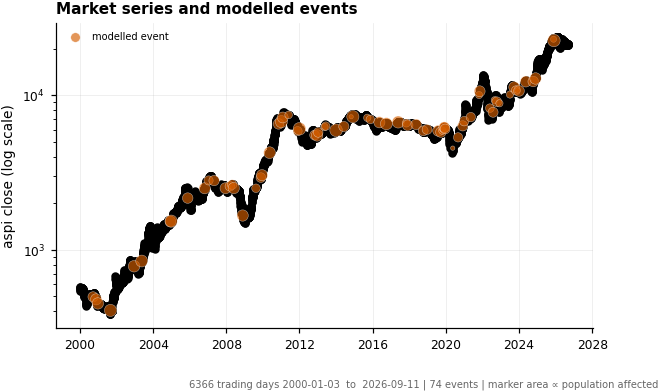

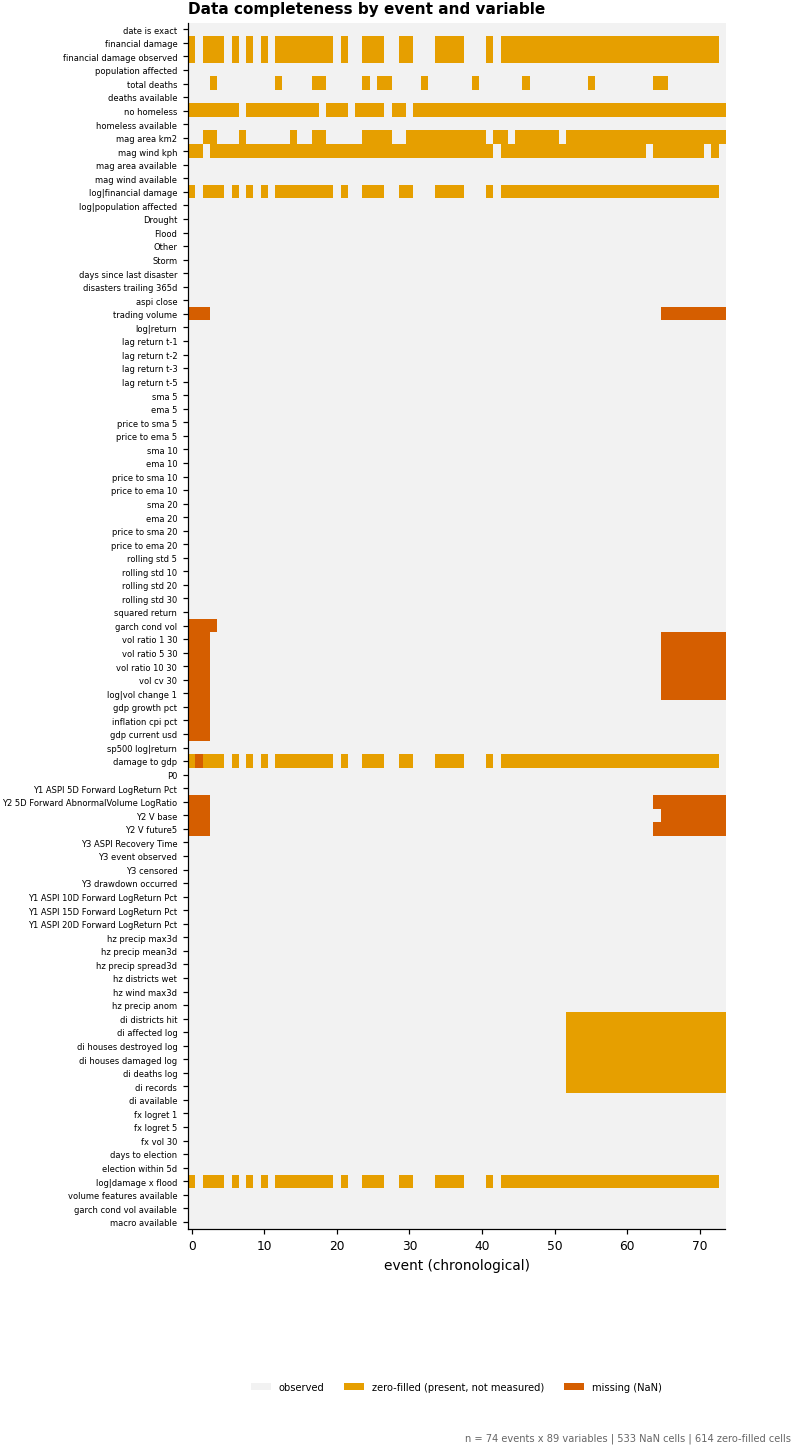

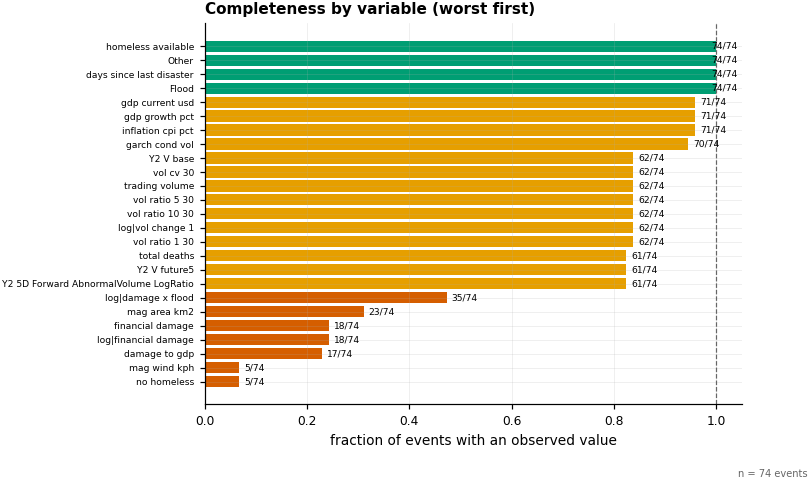

In [2]:
from src.visualization import eda_figures as eda

# 1. Acquisition -- what the market series covers and where the events fall inside it.
market = load_frame("market")
eda.plot_event_timeline(market, dataset)

# 2. Completeness -- the three-state map, then the same thing ranked.
_, completeness_state = eda.plot_missingness_matrix(dataset)
_, completeness = eda.plot_missingness_ranked(dataset)

print("Least complete variables:")
print((completeness.head(8) * 100).round(1).to_string())
print()
_zero = int((completeness_state == 1.0).sum().sum())
_nan = int((completeness_state == 2.0).sum().sum())
print(f"cells that are present but NOT measured (zero-filled): {_zero}")
print(f"cells that are outright missing (NaN):                 {_nan}")
print()
if "damage_source" in dataset.columns:
    print("Damage provenance -- the study's key covariate:")
    print(dataset["damage_source"].value_counts().to_string())
    print(f"  events with a REAL damage figure: "
          f"{int((dataset['financial_damage'] > 0).sum())}/{len(dataset)}")

## 3.3 Outliers

Flagged two ways and **retained, never trimmed**. The IQR fence is conventional; the
modified z-score (median absolute deviation) is reported beside it because IQR fences are
themselves computed from quantiles that a few extreme events can move, and this sample has
exactly that shape.

The extreme events are named on the figure rather than merely counted. An outlier that
turns out to be the 2004 Indian Ocean tsunami is a real observation to be discussed in the
results, not a data error to be removed.

saved -> docs\figures\eda_03_outliers.png (177 KB)
                             variable  n  iqr_outliers  mad_outliers   iqr_lo  iqr_hi
     Y1_ASPI_5D_Forward_LogReturn_Pct 74             8             3  -4.2106  4.4423
Y2_5D_Forward_AbnormalVolume_LogRatio 61             0             0  -1.7169  1.5440
                Y3_ASPI_Recovery_Time 74             8            11 -21.7500 36.2500

Y1_ASPI_5D_Forward_LogReturn_Pct: 8 IQR outliers, 3 MAD outliers
    [datetime.date(2005, 11, 21), datetime.date(2007, 1, 12), datetime.date(2020, 5, 17), datetime.date(2021, 1, 1), datetime.date(2022, 8, 1), datetime.date(2022, 10, 14), datetime.date(2023, 7, 4), datetime.date(2025, 11, 27)]
Y2_5D_Forward_AbnormalVolume_LogRatio: 0 IQR outliers, 0 MAD outliers
Y3_ASPI_Recovery_Time: 8 IQR outliers, 11 MAD outliers
    [datetime.date(2005, 11, 21), datetime.date(2007, 5, 2), datetime.date(2011, 5, 29), datetime.date(2012, 1, 1), datetime.date(2013, 6, 8), datetime.date(2015, 9, 15), datetime.date(

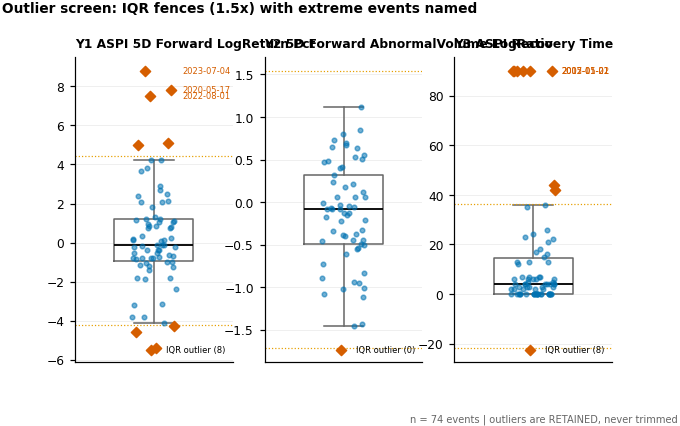

In [3]:
_, outliers = eda.plot_outlier_panel(dataset, TARGET_COLS[:3])
print(outliers.round(4).to_string(index=False))
print()
for _t in TARGET_COLS[:3]:
    _info = eda.outlier_table(dataset[_t])
    _ev = dataset.loc[_info["iqr_outliers"].index, "event_date"].dt.date.tolist()
    print(f"{_t}: {len(_ev)} IQR outliers, {len(_info['mad_outliers'])} MAD outliers")
    if _ev:
        print(f"    {_ev}")

## 3.4 Distributions and normality

Skew and excess kurtosis are annotated on every panel because two things downstream depend
on them: Ridge is a linear model, and the split is chronological. A heavily skewed
predictor whose tail sits entirely inside one fold is a specific, checkable risk rather
than a generic caveat.

The Q-Q panel tests the targets against a normal reference. A low Shapiro p does **not**
invalidate RMSE or R-squared, which make no distributional assumption, but it does rule
out Gaussian confidence intervals, which is why every interval in this study is a
bootstrap.

saved -> docs\figures\eda_04_feature_distributions.png (141 KB)
Most skewed predictors:
                         variable  n      mean    median   skew  excess_kurtosis
            Y3_ASPI_Recovery_Time 74    14.257     4.000  2.340            4.378
                     mag_area_km2 23 24927.047 19891.000  2.208            5.659
                  hz_precip_max3d 74    72.061    64.780  1.925            4.804
Y1_ASPI_10D_Forward_LogReturn_Pct 74     0.937    -0.010  0.907            2.181
 Y1_ASPI_5D_Forward_LogReturn_Pct 74     0.339    -0.121  0.754            1.396
                  di_affected_log 74     8.118    10.970 -0.678           -1.319
                    hz_wind_max3d 74     9.653     9.460  0.610            0.188
          log_population_affected 74    11.418    11.764 -0.530           -0.278



saved -> docs\figures\eda_05_qq_targets.png (170 KB)
                               target  n  shapiro_p  normal_at_5pct
     Y1_ASPI_5D_Forward_LogReturn_Pct 74     0.0026           False
Y2_5D_Forward_AbnormalVolume_LogRatio 61     0.6056            True
                Y3_ASPI_Recovery_Time 74     0.0000           False
    Y1_ASPI_10D_Forward_LogReturn_Pct 74     0.0014           False


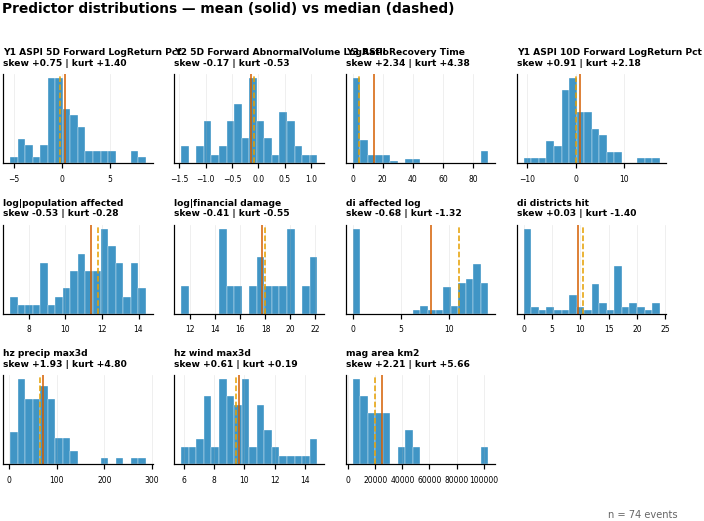

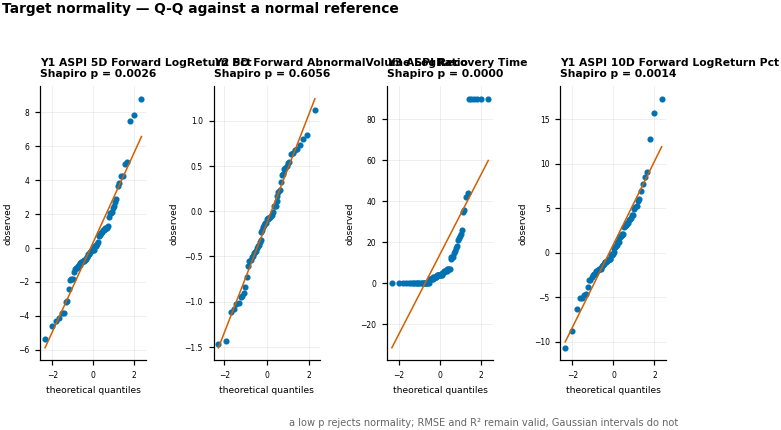

In [4]:
_SEVERITY = [c for c in ("log_population_affected", "log_financial_damage",
                         "di_affected_log", "di_districts_hit", "hz_precip_max3d",
                         "hz_wind_max3d", "mag_area_km2") if c in dataset.columns]

_, shape_stats = eda.plot_feature_distributions(dataset, TARGET_COLS + _SEVERITY)
print("Most skewed predictors:")
print(shape_stats.reindex(shape_stats["skew"].abs().sort_values(ascending=False).index)
      .head(8)[["variable", "n", "mean", "median", "skew", "excess_kurtosis"]]
      .round(3).to_string(index=False))
print()
_, normality = eda.plot_qq_grid(dataset, TARGET_COLS)
print(normality.round(4).to_string(index=False))

## 3.5 Predictor-target relationships

Spearman rather than Pearson: the severity variables are heavily skewed and a relationship
could be monotone without being linear.

**A trend line is drawn only where the correlation clears the critical value at this
sample size.** A fitted line through noise is the most misleading mark that can appear on
a scatter plot, and at n~76 the critical value is roughly 0.23, large enough that most
of these panels should, correctly, carry no line at all.

saved -> docs\figures\eda_06_scatter_matrix.png (348 KB)
target-severity pairs whose |rho| clears the critical value: 4 of 12
                               target                 feature  spearman_rho     p  n  critical_r  distinguishable
     Y1_ASPI_5D_Forward_LogReturn_Pct        di_districts_hit        -0.331 0.004 74       0.228             True
     Y1_ASPI_5D_Forward_LogReturn_Pct         di_affected_log        -0.295 0.011 74       0.228             True
Y2_5D_Forward_AbnormalVolume_LogRatio         di_affected_log        -0.281 0.028 61       0.252             True
                Y3_ASPI_Recovery_Time        di_districts_hit         0.280 0.016 74       0.228             True
Y2_5D_Forward_AbnormalVolume_LogRatio log_population_affected        -0.241 0.062 61       0.252            False
                Y3_ASPI_Recovery_Time         di_affected_log         0.221 0.058 74       0.228            False
     Y1_ASPI_5D_Forward_LogReturn_Pct log_population_affected        -0.219 

saved -> docs\figures\eda_07_corr_Y1_ASPI_5D_Forward_LogReturn_Pct.png (158 KB)
Y1_ASPI_5D_Forward_LogReturn_Pct: strongest predictor is mag_wind_kph (rho=-0.400)


saved -> docs\figures\eda_07_corr_Y2_5D_Forward_AbnormalVolume_LogRatio.png (156 KB)
Y2_5D_Forward_AbnormalVolume_LogRatio: strongest predictor is vol_ratio_1_30 (rho=+0.480)


saved -> docs\figures\eda_07_corr_Y3_ASPI_Recovery_Time.png (148 KB)
Y3_ASPI_Recovery_Time: strongest predictor is mag_wind_kph (rho=+0.300)


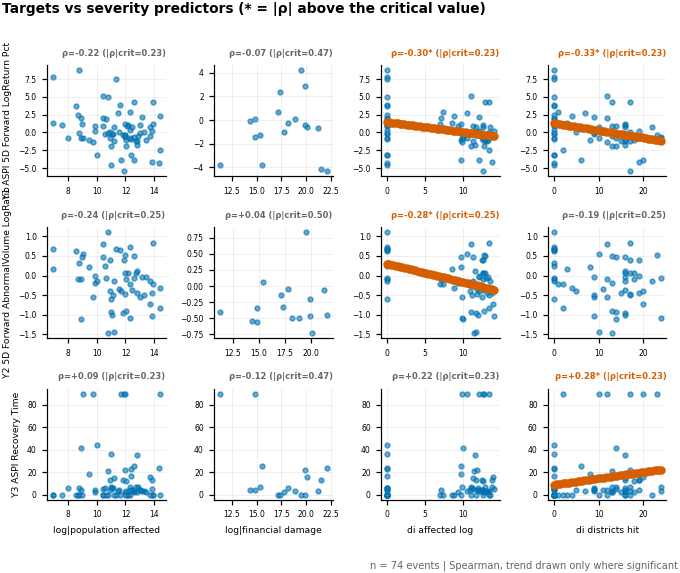

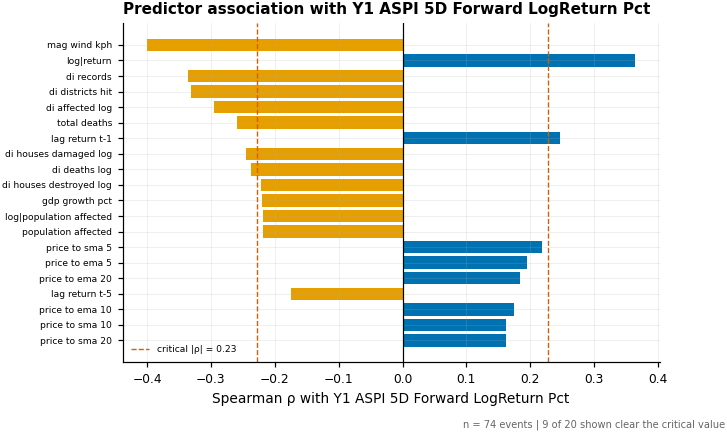

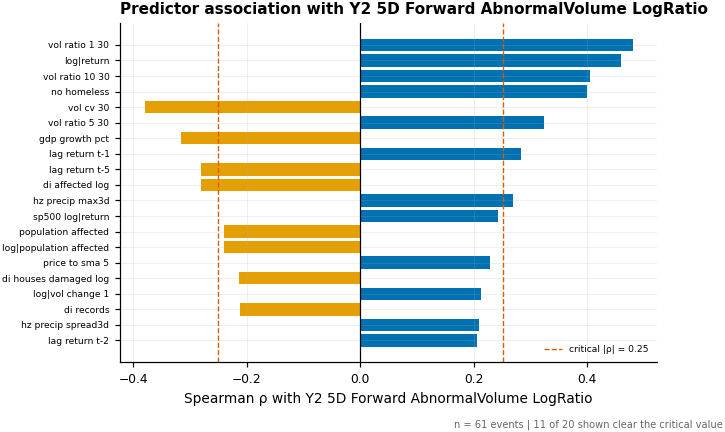

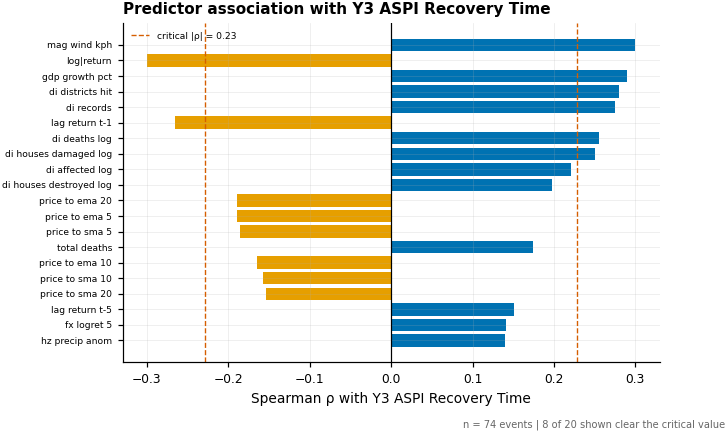

In [5]:
_, assoc = eda.plot_target_scatter_matrix(dataset, TARGET_COLS[:3], _SEVERITY[:4])
_sig = assoc[assoc.distinguishable]
print(f"target-severity pairs whose |rho| clears the critical value: "
      f"{len(_sig)} of {len(assoc)}")
print(assoc.sort_values("spearman_rho", key=abs, ascending=False)
      .head(10).round(3).to_string(index=False))
print()
for _t in TARGET_COLS[:3]:
    _, _bars = eda.plot_feature_target_correlation(dataset, _t, FEATURE_COLS)
    if _bars is not None and len(_bars):
        _top = _bars.iloc[0]
        print(f"{_t}: strongest predictor is {_top.feature} (rho={_top.rho:+.3f})")

## 3.6 Class balance and panel coverage

Prevalence is plotted per classification label **before any model is fitted**, because it
determines what an accuracy figure can possibly mean. A label at prevalence 0.90 hands the
always-predict-majority rule 0.90 accuracy for free, so a model scoring near that has
demonstrated nothing. This is why the reported criterion is balanced accuracy with an AUC
interval, not raw accuracy.

The sector coverage figure shows the panel is unbalanced: five of the twenty indices do
not span the study window.

saved -> docs\figures\eda_09_class_balance.png (142 KB)
             label  n  n_pos  prevalence
C0_drawdown_occurs 74     52       0.703
C1_negative_return 74     38       0.514
  C1b_adverse_move 74     25       0.338
   C2_volume_spike 61     23       0.377
 C3_recovers_in_90 42     36       0.857
 C3b_slow_recovery 42     19       0.452

Labels where raw accuracy is gameable by the majority rule:
  C0_drawdown_occurs: majority rule alone scores 0.703 accuracy
  C1b_adverse_move: majority rule alone scores 0.662 accuracy
  C3_recovers_in_90: majority rule alone scores 0.857 accuracy


saved -> docs\figures\eda_10_sector_coverage.png (170 KB)

sector indices not spanning the window: 5 of 20
            sector        min        max  count
       Plantations 2000-01-03 2020-10-08   4950
    Power & Energy 2002-01-10 2023-06-28   5110
        Healthcare 2002-03-15 2023-06-28   5069
                IT 2002-05-20 2023-06-28   5029
Telecommunications 2003-01-14 2023-06-28   4870

EDA figures exported:
                                             filename  kb
                        eda_01_missingness_matrix.png 429
                        eda_02_missingness_ranked.png 197
                                  eda_03_outliers.png 177
                     eda_04_feature_distributions.png 141
                                eda_05_qq_targets.png 170
                            eda_06_scatter_matrix.png 348
     eda_07_corr_Y1_ASPI_5D_Forward_LogReturn_Pct.png 158
eda_07_corr_Y2_5D_Forward_AbnormalVolume_LogRatio.png 156
                eda_07_corr_Y3_ASPI_Recovery_Time.png 148
  

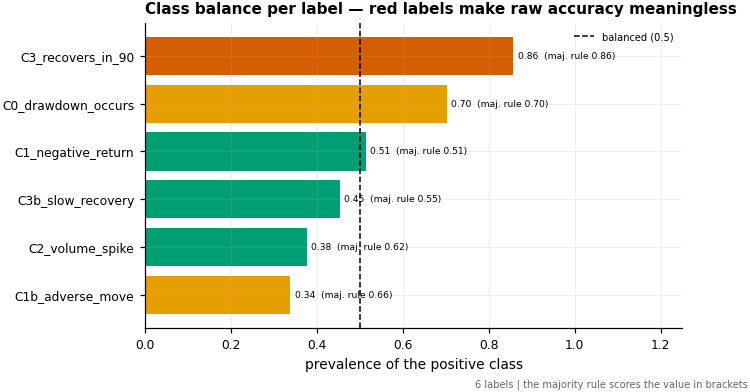

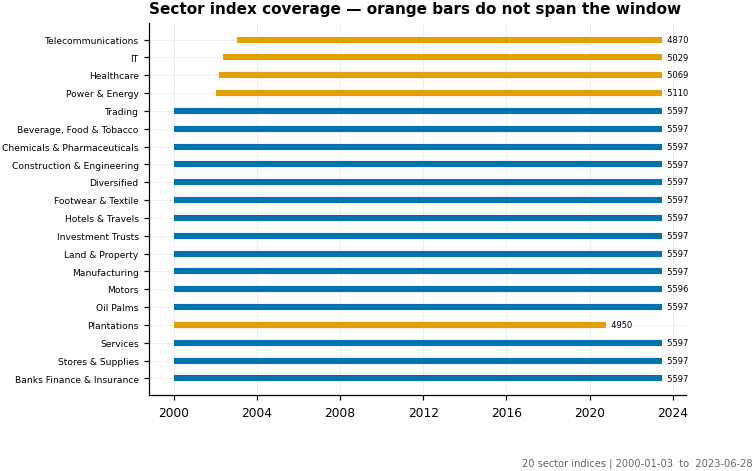

In [6]:
from src.models.classifiers import LABELS

_rows = []
for _name, _fn in LABELS.items():
    _lab = _fn(y, np.arange(len(y)), dataset)
    _rows.append({"label": _name, "n": int(_lab.notna().sum()),
                  "n_pos": int(_lab.sum()), "prevalence": float(_lab.mean())})
label_balance = pd.DataFrame(_rows)
eda.plot_class_balance(label_balance)
print(label_balance.round(3).to_string(index=False))
print()
print("Labels where raw accuracy is gameable by the majority rule:")
for _, _r in label_balance.iterrows():
    _maj = max(_r.prevalence, 1 - _r.prevalence)
    if _maj > 0.65:
        print(f"  {_r.label}: majority rule alone scores {_maj:.3f} accuracy")

try:
    from src.data.cse_market_data import load_sector_indices
    _sector_long = load_sector_indices(CSE_MARKET_INDICES_FILE)
    _, _cov = eda.plot_sector_coverage(_sector_long)
    _short = _cov[(_cov["min"] > _cov["min"].min()) | (_cov["max"] < _cov["max"].max())]
    print()
    print(f"sector indices not spanning the window: {len(_short)} of {len(_cov)}")
    print(_short[["sector", "min", "max", "count"]].to_string(index=False))
except Exception as _e:
    print(f"sector coverage figure skipped: {type(_e).__name__}: {_e}")

print()
print("EDA figures exported:")
print(eda.eda_manifest(FIGURE_DIR).to_string(index=False))

## 3.7 Target distributions

The ECDF row matters more than the histogram row. A histogram of Y3 buries its structure
inside a bin, while the ECDF shows the point mass at 0 and the point mass at the 90-day cap
as two unmistakable vertical jumps. That shape, zero-inflated and right-censored, is why
a single continuous regressor is the wrong model for Y3, and why the training-mean
predictor currently beats every fitted model on it.

saved -> docs\figures\fig_02_target_distributions.png (149 KB)
Y1_ASPI_5D_Forward_LogReturn_Pct n= 74  mean=+0.339  median=-0.1208  sd=2.68  min=-5.397  max=+8.797
Y2_5D_Forward_AbnormalVolume_LogRatio n= 61  mean=-0.1343  median=-0.08342  sd=0.5938  min=-1.464  max=+1.12
Y3_ASPI_Recovery_Time  n= 74  mean=+14.26  median=+4  sd=24.79  min=+0  max=+90
Y1_ASPI_10D_Forward_LogReturn_Pct n= 74  mean=+0.9369  median=-0.009965  sd=4.744  min=-10.7  max=+17.3


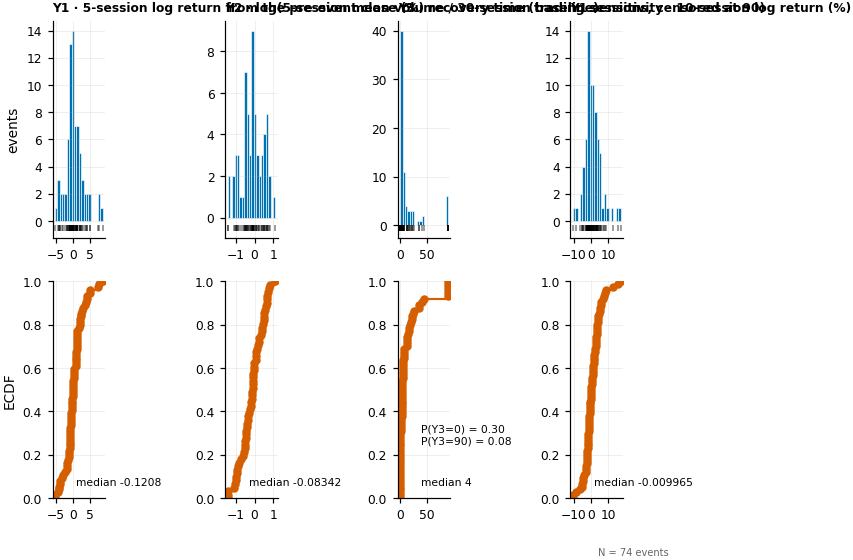

In [7]:
fig = fx.plot_target_distributions(dataset, TARGET_COLS)
fx.save_figure(fig, "fig_02_target_distributions")

for t in TARGET_COLS:
    v = pd.to_numeric(dataset[t], errors="coerce").dropna()
    print(f"{t:<22s} n={len(v):3d}  mean={v.mean():+.4g}  median={v.median():+.4g}  "
          f"sd={v.std():.4g}  min={v.min():+.4g}  max={v.max():+.4g}")


## 3.8 Y3

The recovery window includes the event day and the baseline is the previous close, so any
event with a non-negative event-day return "recovers" on day 0 by construction. The
contingency panel shows the consequence: the cell for *Y1 ≥ 0 and Y3 > 0* is empty. Over
half of Y3 is a mechanical restatement of the sign of Y1, so Y3 performance cannot be read
as independent evidence, and a hurdle model's first stage is close to a sign classifier.

saved -> docs\figures\fig_03_target_dependence_y1_y3.png (139 KB)


WindowsPath('F:/CSE-disaster-impact-predictor/docs/figures/fig_03_target_dependence_y1_y3.png')

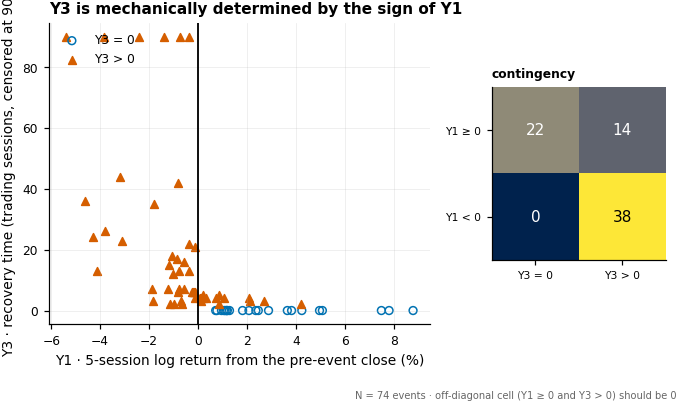

In [8]:
fig = fx.plot_target_dependence_y1_y3(dataset)
fx.save_figure(fig, "fig_03_target_dependence_y1_y3")


## 3.9 Feature correlation

Spearman rather than Pearson, for three reasons specific to this data. `financial_damage`
is zero for 47 of 64 events with a long tail on the remaining 17, so a Pearson coefficient
there is driven by two or three observations. Y3 has point masses at both ends, against
which only a rank measure is defensible. And because Spearman is invariant to monotone
transforms, a column and its own logarithm read exactly **1.00**, not a defect but the
cleanest possible statement that the two are one variable.

Cells below the significance threshold for this sample size are greyed out. With n = 64
that threshold is |ρ| ≈ 0.25; without the mask a reader will point at a 0.3 cell and ask
what it means, when the answer is "nothing".

saved -> docs\figures\fig_04_feature_correlation_heatmap.png (733 KB)


Most redundant feature pairs (Spearman):
                feature_a                 feature_b       rho          group_a
         financial_damage      log_financial_damage  1.000000  damage/severity
      population_affected   log_population_affected  1.000000  damage/severity
            date_is_exact          disaster_Drought -1.000000            other
              no_homeless        homeless_available  0.999218            other
             mag_wind_kph        mag_wind_available  0.999218            other
financial_damage_observed      log_financial_damage  0.987257            other
         financial_damage financial_damage_observed  0.987257  damage/severity
          price_to_sma_10           price_to_ema_10  0.980748 returns/momentum
             mag_area_km2        mag_area_available  0.977468            other
     log_financial_damage             damage_to_gdp  0.970114  damage/severity
         financial_damage             damage_to_gdp  0.970114  damage/severity
          p

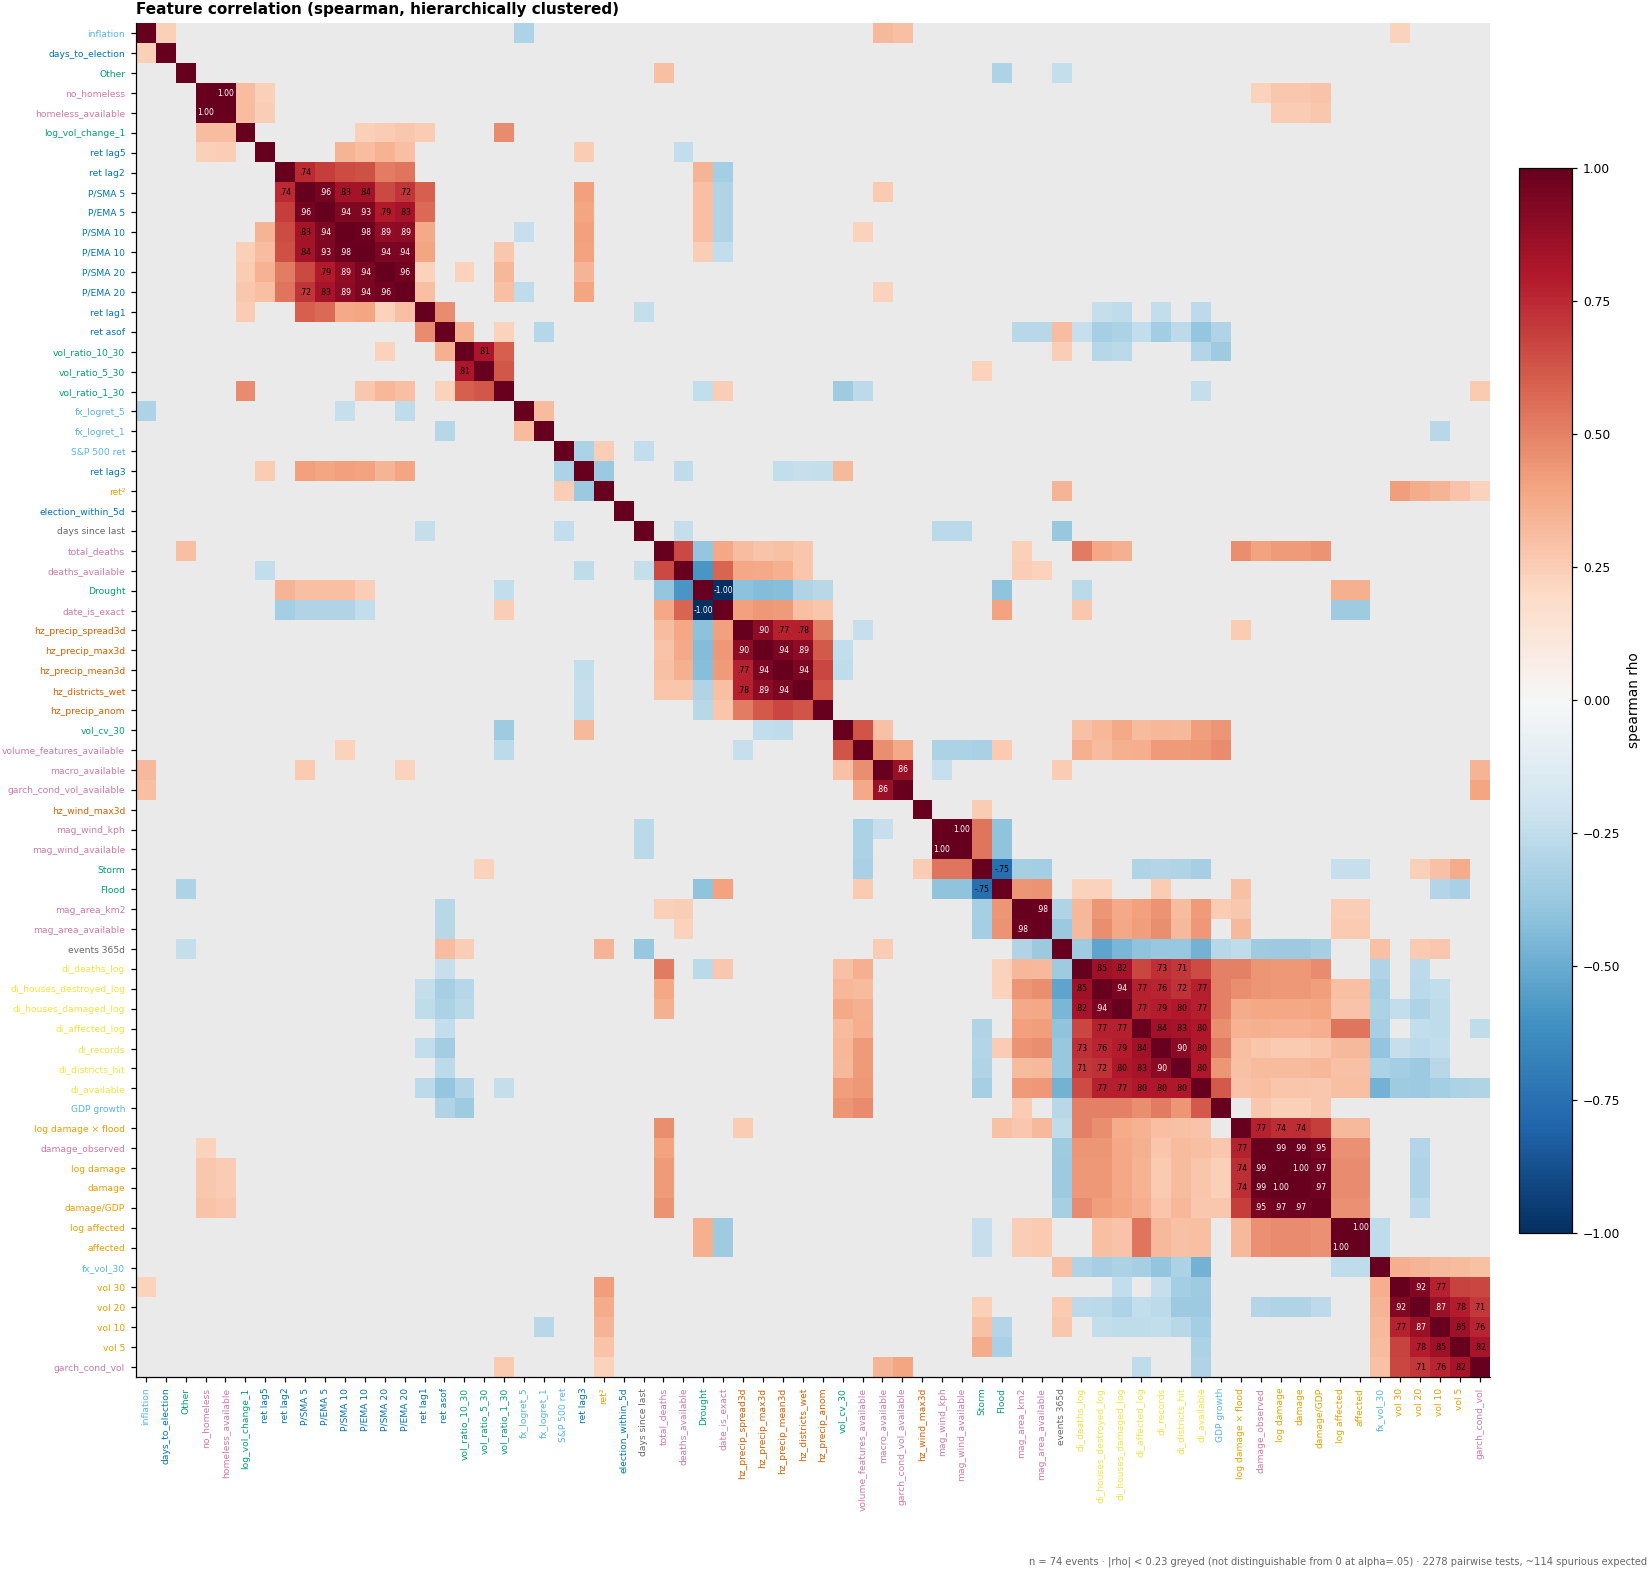

In [9]:
fig = fx.plot_feature_correlation_heatmap(X, method="spearman")
fx.save_figure(fig, "fig_04_feature_correlation_heatmap", formats=("png", "pdf"))

from src.evaluation import collinearity as col

pairs = col.top_correlated_pairs(X, top_n=12)
print("Most redundant feature pairs (Spearman):")
print(pairs[["feature_a", "feature_b", "rho", "group_a"]].to_string(index=False))


### 3.9.1 Variance inflation and condition indices

The same collinearity evidence from a second angle. A correlation heatmap shows
pairwise redundancy; VIF and the condition number catch redundancy spread across
three or more columns, which no pairwise view can see.

saved -> docs\figures\fig_06_collinearity_vif.png (351 KB)
condition number = 35045866369276508  (indices above 30 are the usual concern)


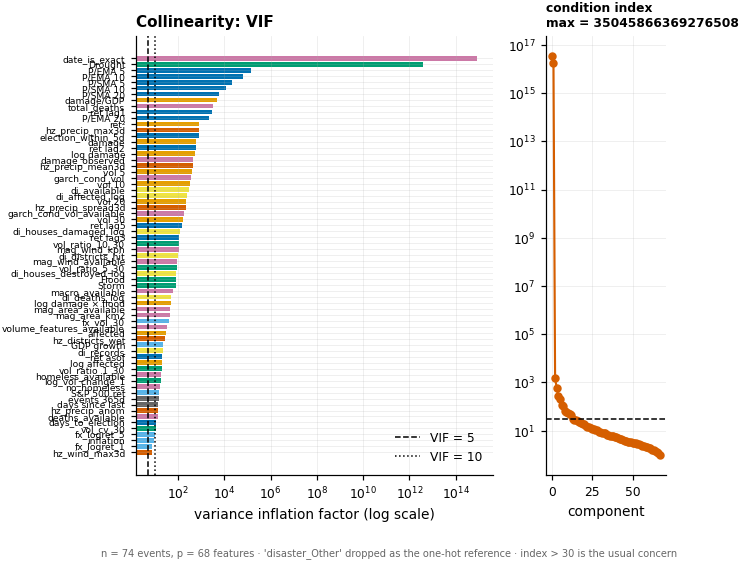

In [10]:
fig = fx.plot_vif(X)
fx.save_figure(fig, "fig_06_collinearity_vif")

ci = col.condition_indices(X)
print(f"condition number = {ci.max():.0f}  (indices above 30 are the usual concern)")


### 3.9.2 The pre-declared redundancy rule

Stated before any model was scored under it, so applying it cannot be selection on test
performance: **within any group of features whose pairwise |ρ| exceeds 0.95, keep the
single most primitive member, the one with the fewest derivation steps from a raw
measurement, and drop the rest.** Ties break alphabetically so the outcome is
deterministic.

The rule never consults a target, a fold or a score. Whatever it does to the metrics is
reported either way.

In [11]:
keep, drop, detail = col.redundant_drop_set(X, threshold=0.95)
print(f"Rule at |rho| >= 0.95: keep {len(keep)} features, drop {len(drop)}.\n")
if len(detail):
    print(detail.to_string(index=False))
else:
    print("No feature pair exceeds the threshold.")

save_json({"keep": keep, "drop": drop, "threshold": 0.95,
           "rule": "within a >=0.95 correlated group keep the least-derived member"},
          "collinearity_rule")


Rule at |rho| >= 0.95: keep 57 features, drop 11.

                  dropped                kept  rho_with_kept            group
         disaster_Drought       date_is_exact       1.000000    disaster type
            damage_to_gdp    financial_damage       0.970114  damage/severity
financial_damage_observed    financial_damage       0.987257            other
     log_financial_damage    financial_damage       1.000000  damage/severity
  log_population_affected population_affected       1.000000  damage/severity
              no_homeless  homeless_available       0.999218            other
             mag_area_km2  mag_area_available       0.977468            other
             mag_wind_kph  mag_wind_available       0.999218            other
           price_to_sma_5      price_to_ema_5       0.955187 returns/momentum
          price_to_sma_10     price_to_ema_10       0.980748 returns/momentum
          price_to_sma_20     price_to_ema_20       0.961318 returns/momentum
cached collin

WindowsPath('F:/CSE-disaster-impact-predictor/artifacts/results/collinearity_rule.json')

## 3.10 Walk-forward geometry

The two largest shocks in the sample, the 2004-12-26 tsunami and the 2005-11-21 flood, 
are events 7 and 8, which places them permanently inside fold 0's *training* window. They
appear in no test fold. The held-out folds therefore carry markedly less variance than the
full sample, and since R² scores against the test set's own mean, that compression is part
of why pooled R² is negative. It also means the reported R² is **conservative**, not
flattering.

saved -> docs\figures\fig_09_walk_forward_folds.png (150 KB)
target                   full sigma   test sigma   ratio
Y1_ASPI_5D_Forward_LogReturn_Pct       2.6797       2.7777    1.04
Y2_5D_Forward_AbnormalVolume_LogRatio      0.59377      0.60732    1.02
Y3_ASPI_Recovery_Time        24.787        21.48    0.87
Y1_ASPI_10D_Forward_LogReturn_Pct       4.7435       5.1343    1.08


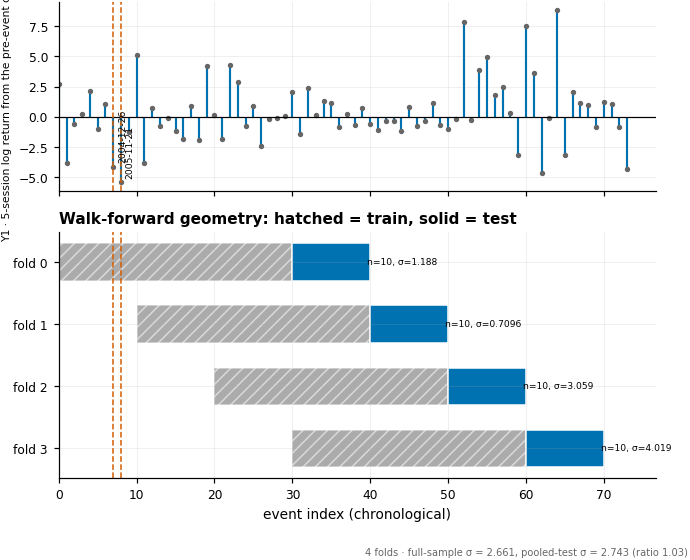

In [12]:
splits = load_object("splits")
fig = fx.plot_walk_forward_folds(splits, dataset, y)
fx.save_figure(fig, "fig_09_walk_forward_folds", formats=("png", "pdf"))

import numpy as np

test_idx = np.concatenate([np.asarray(s.test_index) for s in splits])
print(f"{'target':<22s} {'full sigma':>12s} {'test sigma':>12s} {'ratio':>7s}")
for t in TARGET_COLS:
    v = pd.to_numeric(y[t], errors="coerce")
    full, test = v.std(), v.iloc[test_idx].std()
    print(f"{t:<22s} {full:12.5g} {test:12.5g} {test / full:7.2f}")


## 3.11 What the damage features actually measure

Most Sri Lankan EM-DAT records carry no damage estimate, and the loader zero-fills them.
The damage block therefore behaves substantially as an indicator of **EM-DAT reporting
coverage**, itself correlated with severity and recency, rather than as a clean severity
measure. The interaction term `log_damage_x_flood` rests on an even narrower base.

In [13]:
if "damage_source" in dataset.columns:
    print(dataset["damage_source"].value_counts().to_string())
    has = int((dataset["financial_damage"] > 0).sum())
    print(f"\nevents with a real damage figure: {has}/{len(dataset)}")
    if "disaster_Flood" in dataset.columns:
        supp = int(((dataset["financial_damage"] > 0) & (dataset["disaster_Flood"] == 1)).sum())
        print(f"of which floods -- the entire support of log_damage_x_flood: {supp}")

print("\nExported figures:")
print(fx.figure_manifest().to_string(index=False))


damage_source
missing_median_imputed    56
emdat_cpi_adjusted        18

events with a real damage figure: 18/74
of which floods -- the entire support of log_damage_x_flood: 12

Exported figures:
                              filename  kb
       fig_02_target_distributions.png 149
    fig_03_target_dependence_y1_y3.png 139
fig_04_feature_correlation_heatmap.png 733
           fig_06_collinearity_vif.png 351
         fig_09_walk_forward_folds.png 150
         fig_11_conformal_coverage.png 108
                fig_14_roc_with_ci.png 198
    fig_17_model_vs_naive_baseline.png 144
 fig_18_skill_forest_vs_naive_zero.png 104
fig_18b_skill_forest_vs_train_mean.png 105
          fig_19_pred_vs_actual_y1.png 165
          fig_19_pred_vs_actual_y2.png 167
          fig_19_pred_vs_actual_y3.png 153
            fig_24_overfitting_gap.png 195
  fig_31_sector_response_and_skill.png 215


## 3.12 Final Outputs

This stage describes the data. It fits no model and modifies no cached table.

1. Exploratory figures written to `docs/figures/`: the missingness matrix and ranking, the
   outlier panel, the feature distributions, the target quantile plots, the scatter matrix,
   the per target correlation panels, the event timeline, the class balance and the sector
   coverage.
2. Diagnostic figures for the modelling stage: the target distributions, the dependence
   between the return and recovery targets, the feature correlation heatmap, the variance
   inflation panel and the walk forward fold geometry.
3. No cached table is written here. The redundancy rule is reported, and the columns it
   would drop are listed, but the drop itself happens inside every fold in stage 04.
4. Consumed next by the thesis data chapter and by `04_modeling_regression.ipynb`, which
   applies the same pre declared rule.

Execution assumption: stage 02 has run and `dataset.parquet` exists.
